In [11]:
import numpy as np
import pandas as pd
# Step 1: Generate 500 fake driving sessions
np.random.seed(42)
n = 500
speed   = np.random.uniform(20, 140, n)      # km/h
terrain = np.random.uniform(0, 15, n)        # slope in %
braking = np.random.randint(0, 30, n)        # number of hard brakes
ac_load = np.random.randint(0, 6, n)         # 0=off, 5=max AC
# Energy use formula (higher = worse)
energy = (80
          + 0.6 * (speed - 60)
          + 4.0 * terrain
          + 1.8 * braking
          + 5.0 * ac_load
          + np.random.normal(0, 8, n))        # add noise
energy = np.clip(energy, 60, 250)            # keep realistic
df = pd.DataFrame({
    'speed': speed,
    'terrain': terrain,
    'braking': braking,
    'ac_load': ac_load,
    'energy_wh_per_km': energy
})
df.to_csv('driving_data.csv', index=False)
print(" Data generated! Shape:", df.shape)
print(df.head())

 Data generated! Shape: (500, 5)
        speed    terrain  braking  ac_load  energy_wh_per_km
0   64.944814  10.472426       14        4        173.176276
1  134.085717   8.041445       11        1        191.049756
2  107.839273   4.642914       29        5        209.925590
3   91.839018  12.206925       15        1        177.743398
4   38.722237  10.270968       23        5        168.728130



 Data summary:
        speed  terrain  braking  ac_load  energy_wh_per_km
count  500.00   500.00   500.00   500.00            500.00
mean    79.83     7.23    15.03     2.46            160.09
std     35.84     4.28     8.71     1.72             32.17
min     20.61     0.07     0.00     0.00             75.10
25%     48.95     3.44     7.75     1.00            138.01
50%     81.58     7.08    15.00     3.00            161.25
75%    110.73    10.90    23.00     4.00            183.55
max    139.16    15.00    29.00     5.00            245.08


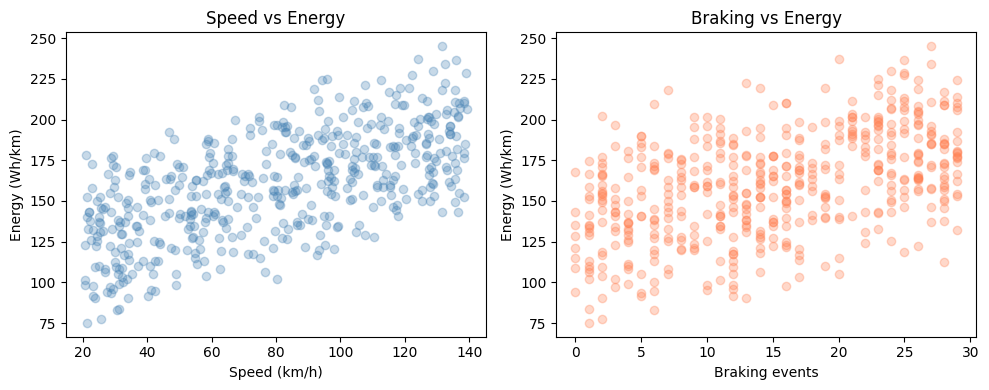

 Chart saved!


In [12]:
import matplotlib.pyplot as plt
print("\n Data summary:")
print(df.describe().round(2))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(df['speed'], df['energy_wh_per_km'], alpha=0.3, color='steelblue')
plt.xlabel('Speed (km/h)')
plt.ylabel('Energy (Wh/km)')
plt.title('Speed vs Energy')

plt.subplot(1, 2, 2)
plt.scatter(df['braking'], df['energy_wh_per_km'], alpha=0.3, color='coral')
plt.xlabel('Braking events')
plt.ylabel('Energy (Wh/km)')
plt.title('Braking vs Energy')

plt.tight_layout()
plt.savefig('data_exploration.png')
plt.show()
print(" Chart saved!")

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
# Features (inputs) and label (what we want to predict)
features = ['speed', 'terrain', 'braking', 'ac_load']
X = df[features]
y = df['energy_wh_per_km']
# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)
# Evaluate the model
y_pred = model.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"\n Model trained!")
print(f"   Mean Absolute Error : {mae:.2f} Wh/km")
print(f"   R² Score            : {r2:.4f}  (1.0 = perfect)")

print("\n Feature importance:")
for feat, coef in zip(features, model.coef_):
    print(f"   {feat:10s} → {coef:+.2f} Wh/km per unit")


 Model trained!
   Mean Absolute Error : 5.67 Wh/km
   R² Score            : 0.9484  (1.0 = perfect)

 Feature importance:
   speed      → +0.58 Wh/km per unit
   terrain    → +4.01 Wh/km per unit
   braking    → +1.70 Wh/km per unit
   ac_load    → +4.85 Wh/km per unit


In [15]:
def predict_and_advise(speed, terrain, braking, ac_load):
    """Takes a driving session and gives AI tips."""
    input_data = pd.DataFrame([[speed, terrain, braking, ac_load]],
                              columns=features)
    predicted_energy = model.predict(input_data)[0]
    score = max(0, min(100, int(100 * (220 - predicted_energy) / (220 - 80))))
    print("\n" + "="*50)
    print(f"   DRIVING EFFICIENCY REPORT")
    print("="*50)
    print(f"  Speed       : {speed} km/h")
    print(f"  Terrain     : {terrain}% grade")
    print(f"  Braking     : {braking} hard events")
    print(f"  AC load     : {ac_load}/5")
    print(f"  Predicted   : {predicted_energy:.1f} Wh/km")
    print(f"  Efficiency  : {score}/100")
    print("-"*50)
    print("   AI TIPS:")
    tips = []
    if speed > 100:
        tips.append("Reduce speed to below 100 km/h — drag increases sharply above 100.")
    if braking > 15:
        tips.append(f"You braked hard {braking} times. Look further ahead to coast instead.")
    if terrain > 8:
        tips.append("Steep terrain detected — use engine braking on downhills.")
    if ac_load >= 4:
        tips.append("High AC use. Pre-cool your car while parked/charging.")
    if score >= 80:
        tips.append("Excellent driving! Keep your smooth, consistent style.")
    if not tips:
        tips.append("Good session overall. Minor improvements still possible.")
    for i, tip in enumerate(tips, 1):
        print(f"  {i}. {tip}")
    print("="*50)
    
predict_and_advise(speed=115, terrain=5, braking=18, ac_load=4)
predict_and_advise(speed=75,  terrain=2, braking=4,  ac_load=1)


   DRIVING EFFICIENCY REPORT
  Speed       : 115 km/h
  Terrain     : 5% grade
  Braking     : 18 hard events
  AC load     : 4/5
  Predicted   : 184.0 Wh/km
  Efficiency  : 25/100
--------------------------------------------------
   AI TIPS:
  1. Reduce speed to below 100 km/h — drag increases sharply above 100.
  2. You braked hard 18 times. Look further ahead to coast instead.
  3. High AC use. Pre-cool your car while parked/charging.

   DRIVING EFFICIENCY REPORT
  Speed       : 75 km/h
  Terrain     : 2% grade
  Braking     : 4 hard events
  AC load     : 1/5
  Predicted   : 110.6 Wh/km
  Efficiency  : 78/100
--------------------------------------------------
   AI TIPS:
  1. Good session overall. Minor improvements still possible.
